# Day 2 — Feature Engineering: EDA Notebook
Adaptive Defect Prediction Engine

In [37]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('Environment ready.')

Environment ready.


## 1. Load & Inspect Feature Matrix

In [38]:
FEATURE_MATRIX_PATH = PROJECT_ROOT / 'data' / 'processed' / 'feature_matrix.csv'
RAW_KC1_PATH        = PROJECT_ROOT / 'data' / 'processed' / 'kc1_labeled.csv'

df     = pd.read_csv(FEATURE_MATRIX_PATH)
kc1_raw = pd.read_csv(RAW_KC1_PATH)

# Normalise column name variant across PROMISE downloads
if 'loccodeandcomment' in kc1_raw.columns:
    kc1_raw = kc1_raw.rename(columns={'loccodeandcomment': 'lines_code_and_comment'})

print(f'Feature matrix : {df.shape[0]:,} rows × {df.shape[1]} cols')
print()
print('All columns and dtypes:')
for col in df.columns:
    n_nan = df[col].isna().sum()
    tag = f'  [{n_nan} NaN]' if n_nan else ''
    print(f'  {col:<40s} {str(df[col].dtype):<10s}{tag}')

Feature matrix : 2,109 rows × 33 cols

All columns and dtypes:
  file_path                                object    
  is_buggy                                 int64     
  lines_of_code                            float64   
  cyclomatic_complexity                    float64   
  essential_complexity                     float64   
  design_complexity                        float64   
  halstead_length                          float64   
  halstead_volume                          float64   
  halstead_level                           float64   
  halstead_difficulty                      float64   
  halstead_intelligence                    float64   
  halstead_effort                          float64   
  halstead_bugs                            float64   
  halstead_time                            float64   
  lines_of_code_clean                      int64     
  lines_of_comments                        int64     
  lines_blank                              int64     
  lines_code_and_co

In [39]:
label_counts = df['is_buggy'].value_counts()
print('Label distribution:')
print(label_counts)
print(f'\nBuggy rate: {100 * label_counts.get(1, 0) / len(df):.1f}%')

# Separate KC1 features vs process/AST to understand coverage
KC1_COLS = [
    'lines_of_code','cyclomatic_complexity','essential_complexity','design_complexity',
    'halstead_length','halstead_volume','halstead_level','halstead_difficulty',
    'halstead_intelligence','halstead_effort','halstead_bugs','halstead_time',
    'lines_of_code_clean','lines_of_comments','lines_blank','lines_code_and_comment',
    'unique_operators','unique_operands','total_operators','total_operands','branch_count',
]
PROCESS_COLS = [
    'code_churn_30d','code_churn_90d','commit_count_30d','commit_count_90d',
    'author_count_90d','bug_fix_count_90d','fix_density','days_since_last_change',
    'commit_burst_30d','ownership_score',
]
AST_COLS = [
    'ast_cyclomatic_complexity','ast_cognitive_complexity','max_nesting_depth',
    'num_functions','num_classes','avg_function_length','num_imports',
    'ast_node_count','has_try_except','max_args_per_function',
]

kc1_present  = [c for c in KC1_COLS     if c in df.columns]
proc_present = [c for c in PROCESS_COLS if c in df.columns]
ast_present  = [c for c in AST_COLS     if c in df.columns]

def coverage(cols):
    if not cols: return 0.0
    return 100 * (1 - df[cols].isna().all(axis=1).mean())

print(f'\nFeature group coverage (% of modules with at least 1 non-NaN):')
print(f'  KC1 static  : {coverage(kc1_present):.1f}%  ({len(kc1_present)} cols)')
print(f'  Process     : {coverage(proc_present):.1f}%  ({len(proc_present)} cols)')
print(f'  AST         : {coverage(ast_present):.1f}%  ({len(ast_present)} cols)')

Label distribution:
is_buggy
0    1783
1     326
Name: count, dtype: int64

Buggy rate: 15.5%

Feature group coverage (% of modules with at least 1 non-NaN):
  KC1 static  : 100.0%  (21 cols)
  Process     : 0.0%  (0 cols)
  AST         : 0.0%  (10 cols)


## 2. Missing Value Heatmap

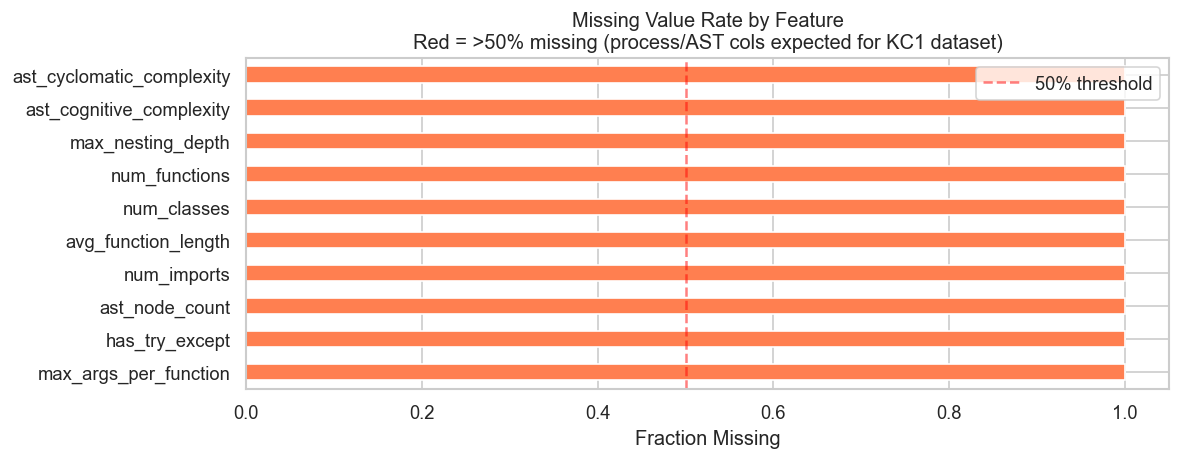


Note: Process and AST columns are NaN for KC1 modules because KC1 is a C
codebase with no matching entries in the Flask Python commit history.
XGBoost handles NaN natively via its split-finding algorithm.


In [40]:
numeric_df = df.select_dtypes(include=[np.number])
missing = numeric_df.isnull().mean().sort_values(ascending=False)
missing_nonzero = missing[missing > 0]

if missing_nonzero.empty:
    print('No missing values in numeric columns.')
else:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_nonzero) * 0.35)))
    colors = ['coral' if v > 0.5 else 'steelblue' for v in missing_nonzero.values]
    missing_nonzero.plot(kind='barh', ax=ax, color=colors)
    ax.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='50% threshold')
    ax.set_title('Missing Value Rate by Feature\n'
                 'Red = >50% missing (process/AST cols expected for KC1 dataset)')
    ax.set_xlabel('Fraction Missing')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print('\nNote: Process and AST columns are NaN for KC1 modules because KC1 is a C')
    print('codebase with no matching entries in the Flask Python commit history.')
    print('XGBoost handles NaN natively via its split-finding algorithm.')

## 3. Feature Distributions: Buggy vs Clean

### 3a. KC1 Static Features (complete coverage — always plot these)

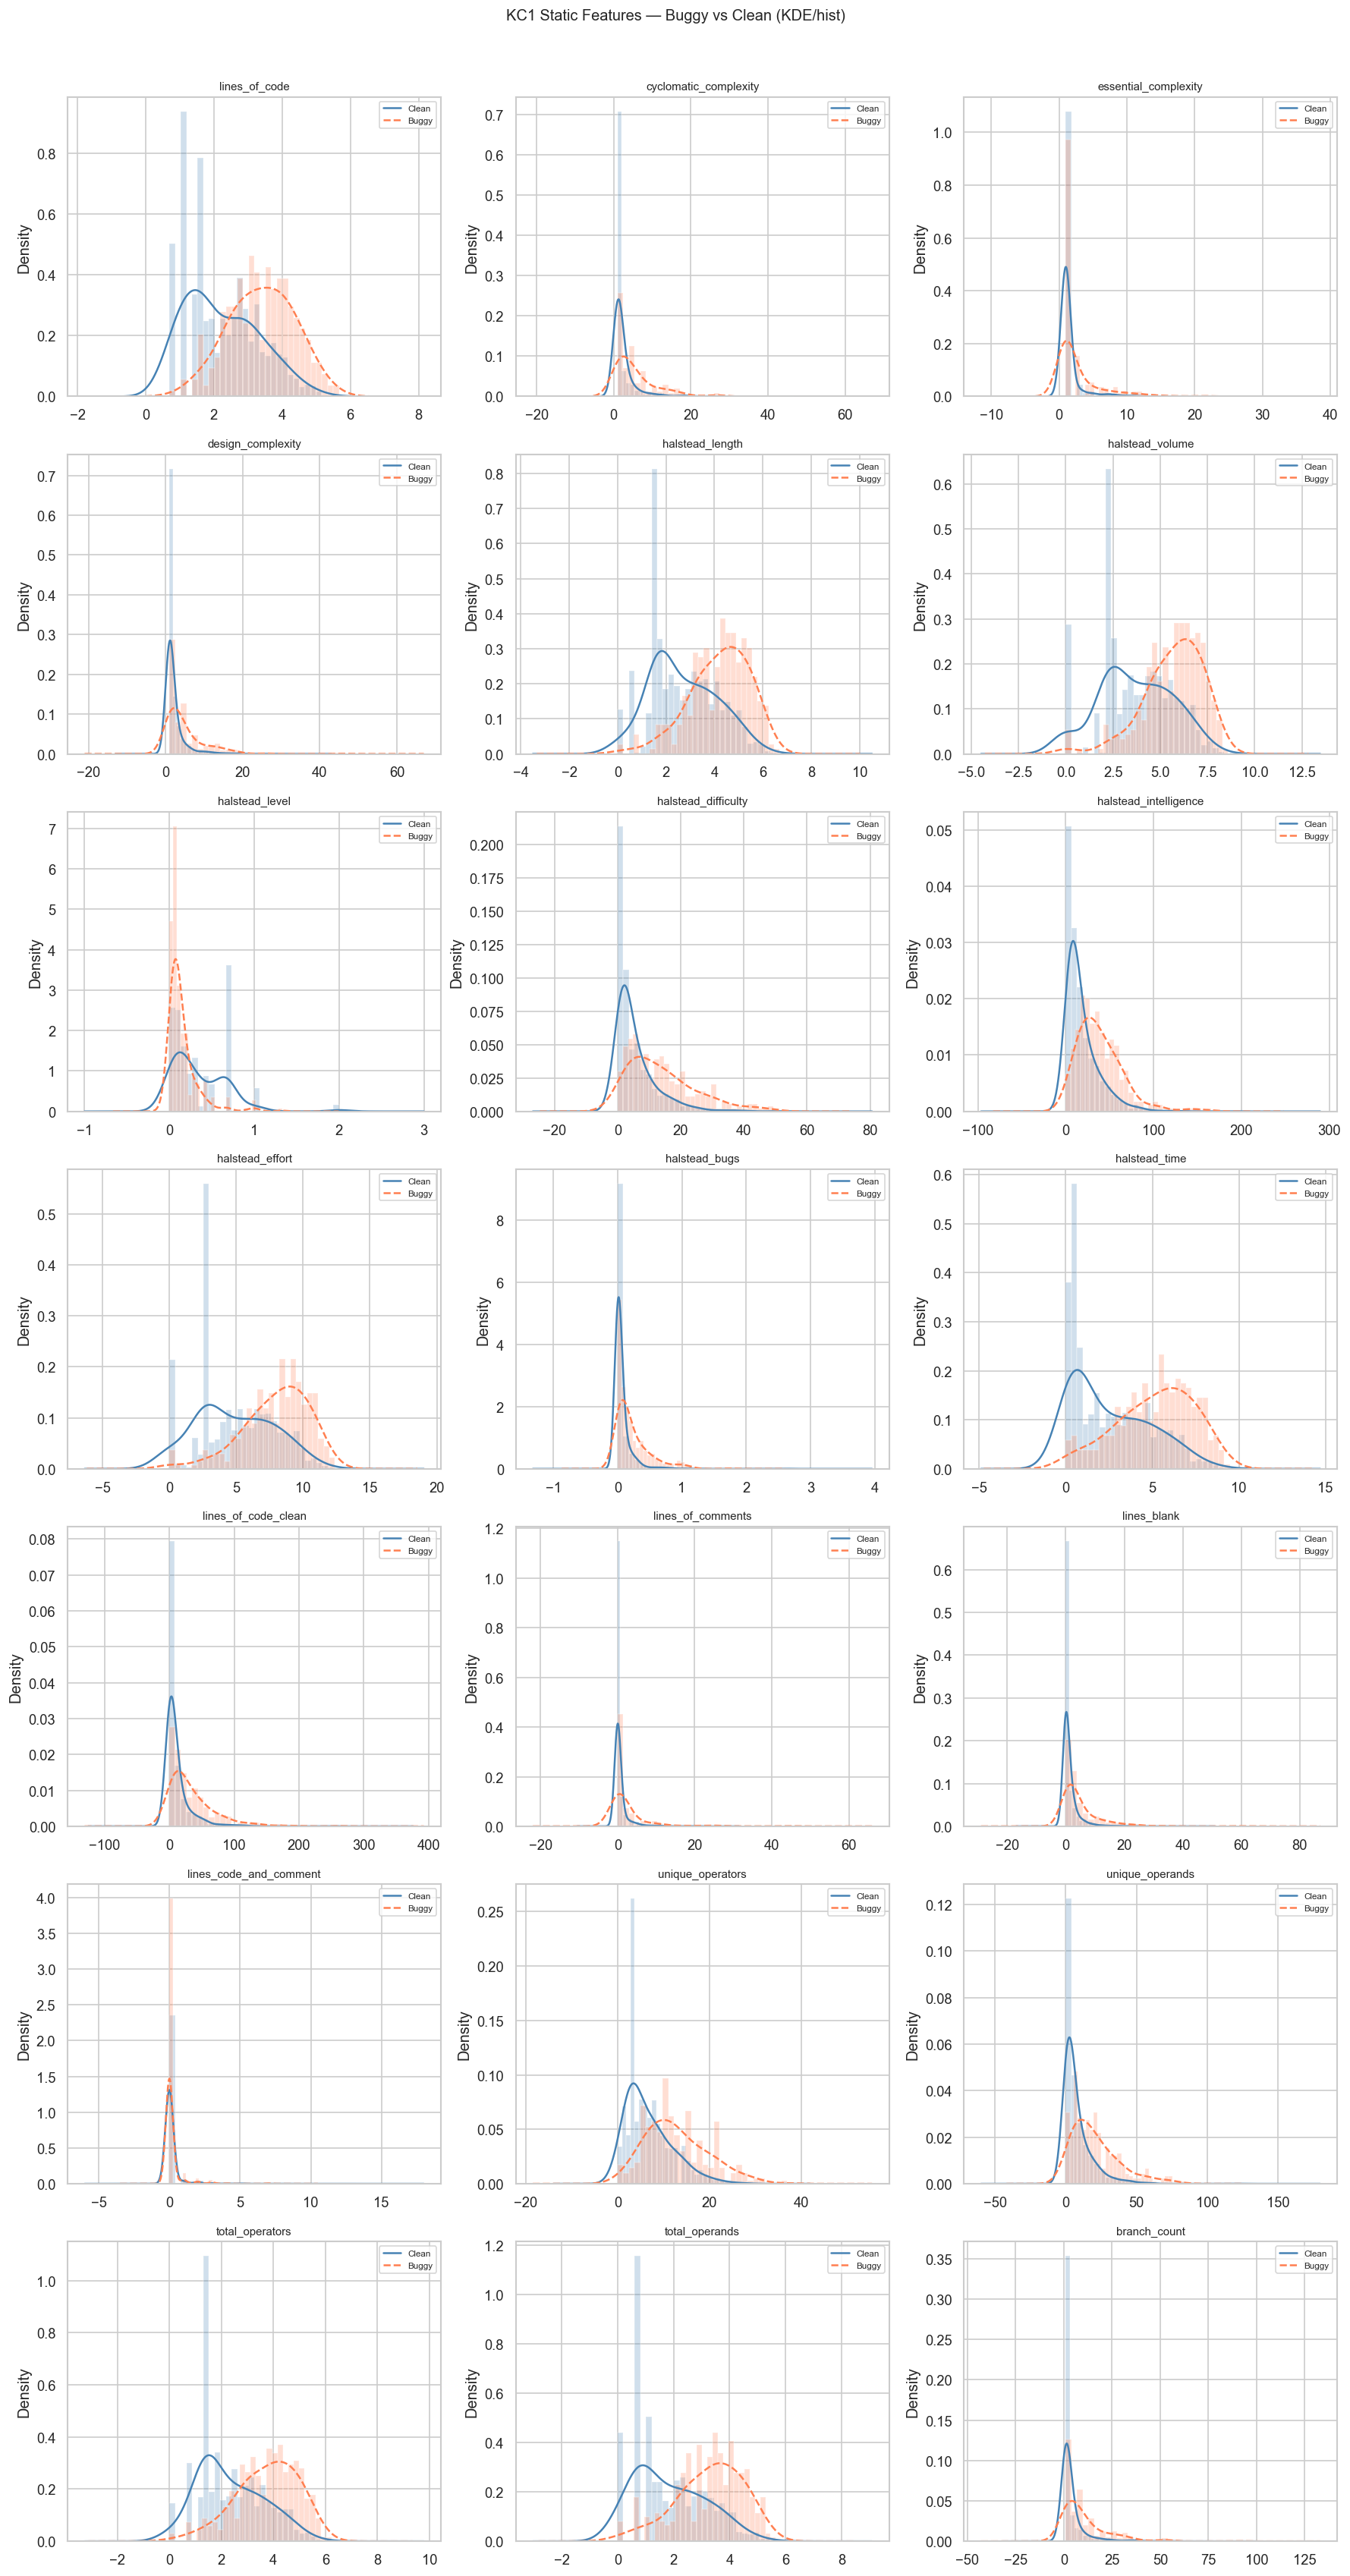

In [41]:
def plot_distributions(features, title, df, label_col='is_buggy', min_nonzero=5):
    """
    Plot KDE + histogram for each feature, split by label.
    Skips features where both classes have fewer than min_nonzero non-NaN values.
    Flags degenerate features (all-zero or all-NaN) with a text notice.
    """
    available = [f for f in features if f in df.columns]
    if not available:
        print(f'No columns available for: {title}')
        return

    ncols = 3
    nrows = (len(available) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
    axes = axes.flatten()

    for i, feat in enumerate(available):
        ax = axes[i]
        plotted = False
        for label, color, ls, name in [
            (0, 'steelblue', '-',  'Clean'),
            (1, 'coral',     '--', 'Buggy'),
        ]:
            subset = df[df[label_col] == label][feat].dropna()
            if len(subset) < min_nonzero:
                continue
            unique_vals = subset.nunique()
            # Histogram as background
            ax.hist(subset, bins=30, density=True, alpha=0.25, color=color)
            # KDE only when there's enough variance
            if unique_vals > 3 and subset.std() > 0:
                subset.plot.kde(ax=ax, label=name, color=color, linestyle=ls, bw_method=0.4)
                plotted = True
            else:
                ax.axvline(subset.median(), color=color, linestyle=ls, label=f'{name} (median)')
                plotted = True

        if not plotted:
            nan_pct = 100 * df[feat].isna().mean()
            ax.text(0.5, 0.5, f'{nan_pct:.0f}% NaN\n(no git match)',
                    ha='center', va='center', transform=ax.transAxes,
                    fontsize=10, color='grey')
            ax.set_title(feat, fontsize=9, color='grey')
        else:
            ax.set_title(feat, fontsize=9)
            ax.legend(fontsize=7)
        ax.set_xlabel('')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f'{title} — Buggy vs Clean (KDE/hist)', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

# Only use KC1 columns that are actually present in the feature matrix
plot_distributions(kc1_present, 'KC1 Static Features', df)

### 3b. Process & AST Features
These will show as grey "NaN" panels if KC1 modules had no matching git commits (expected for this cross-dataset setup).

No columns available for: Process Features


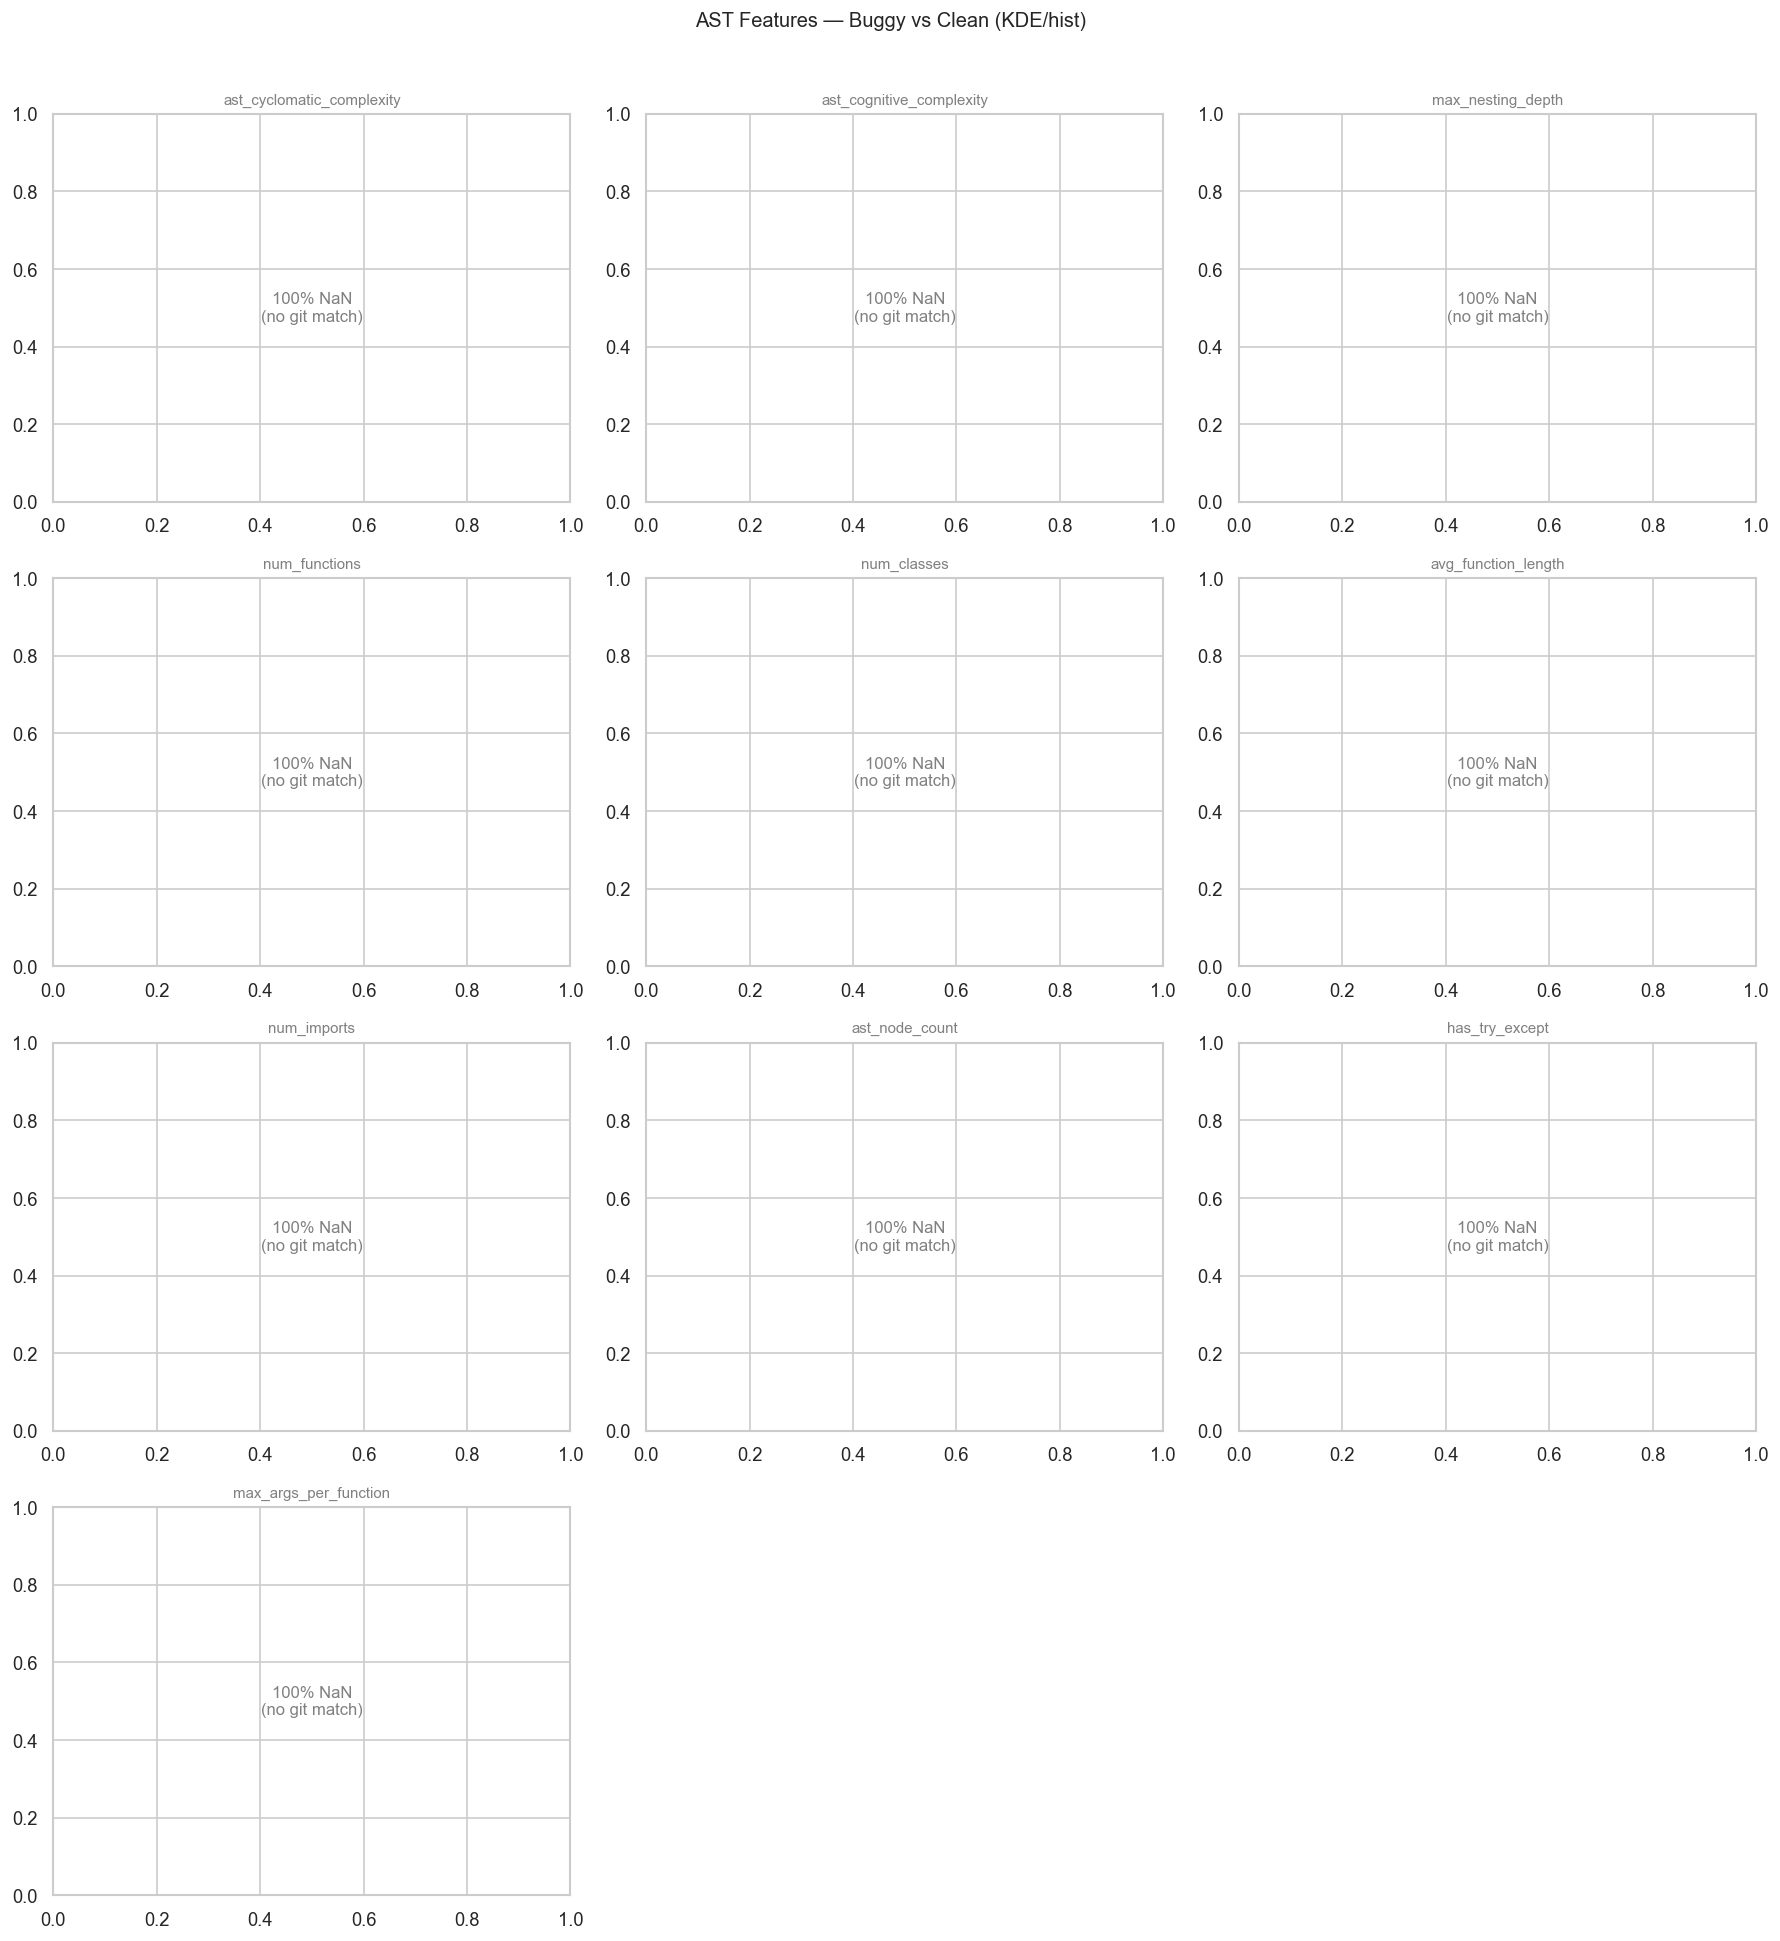

In [42]:
plot_distributions(proc_present, 'Process Features', df)
plot_distributions(ast_present,  'AST Features', df)

## 4. Correlation Analysis

KC1 static features have rich correlations (Halstead metrics are mathematically derived from each other).  
Process/AST features are analysed separately — they're mostly NaN for KC1 so Spearman on the full matrix would just show near-zero values for those columns.

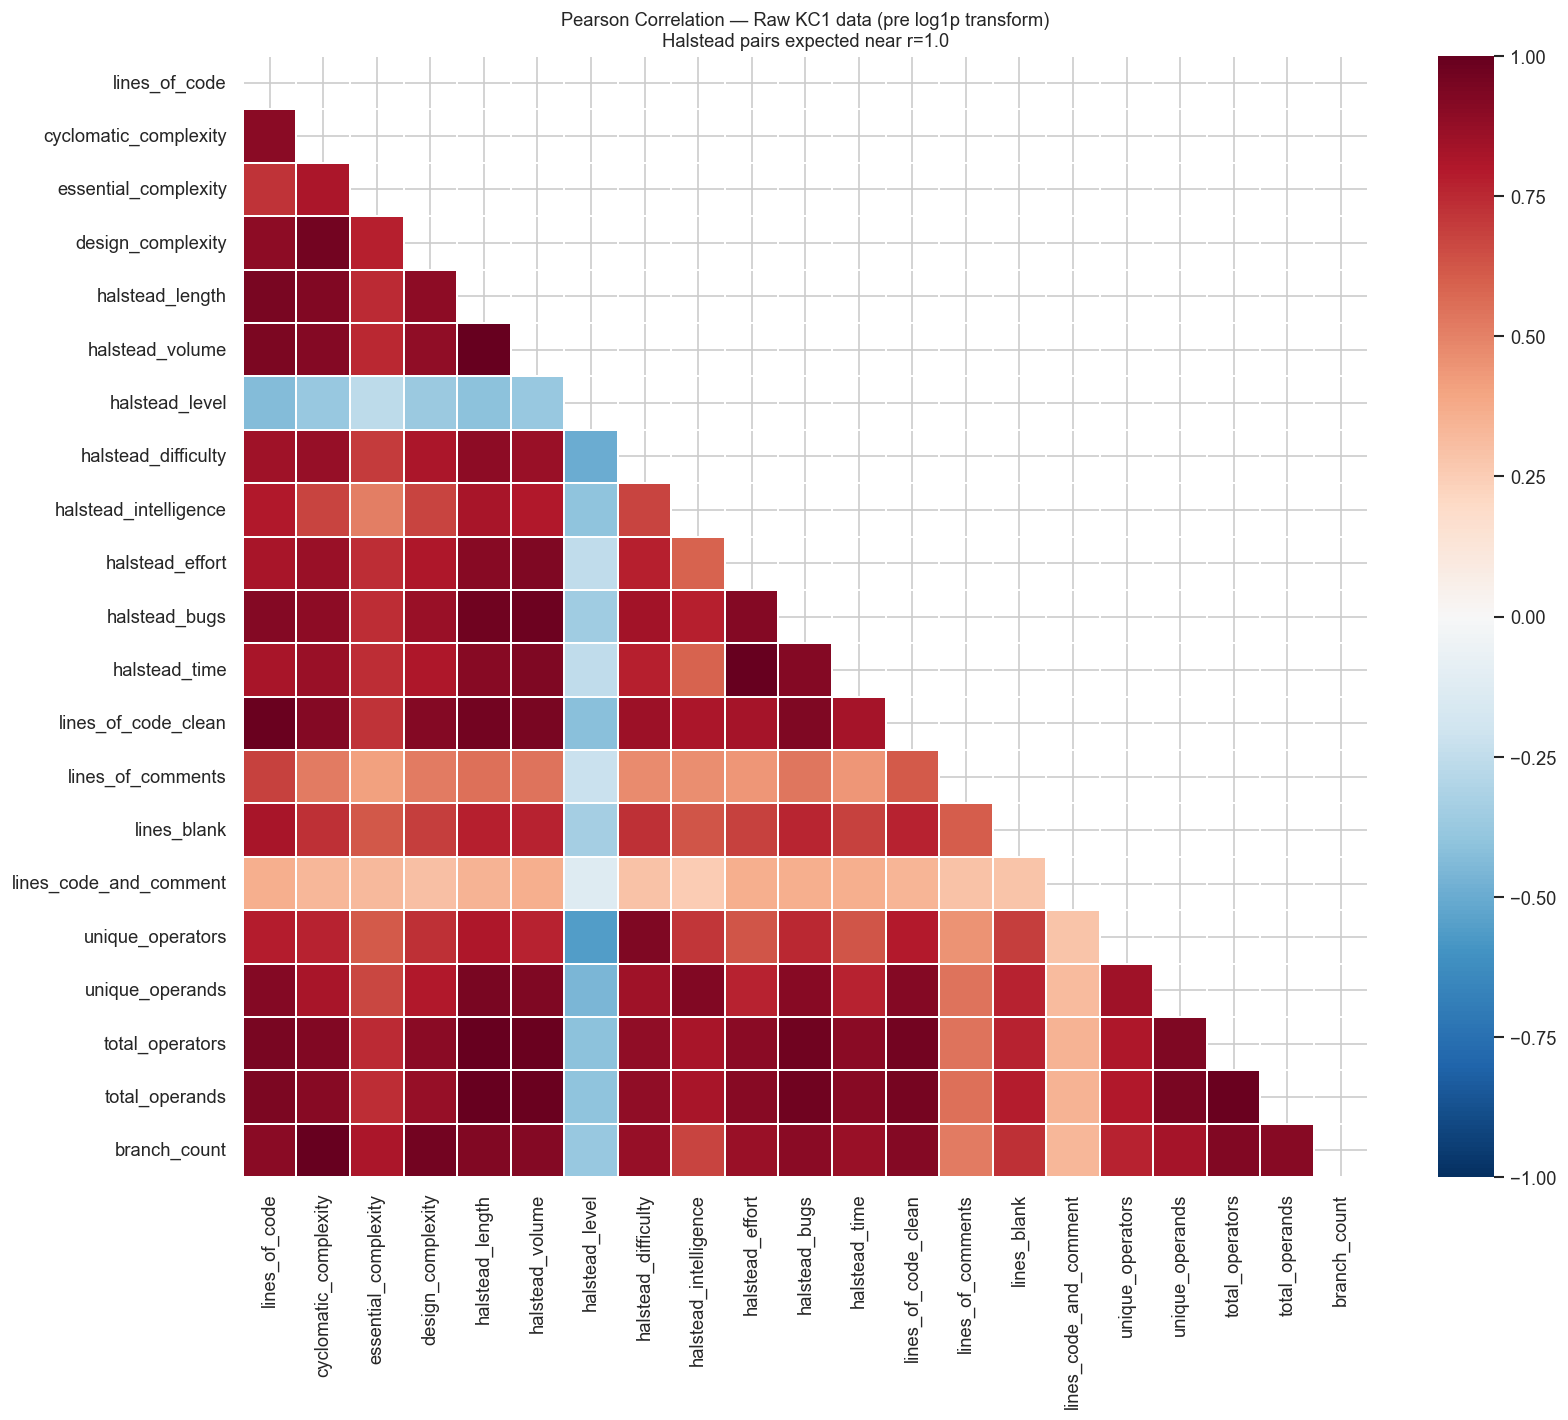

In [43]:
# ── 4a. Pearson on raw KC1 data (pre-transform, no NaN issues) ────────────
kc1_num_cols = [c for c in kc1_raw.select_dtypes(include=[np.number]).columns
                if c not in ('is_buggy',) and kc1_raw[c].notna().sum() > 10]

pearson_raw = kc1_raw[kc1_num_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(pearson_raw, dtype=bool))
sns.heatmap(pearson_raw, mask=mask, annot=False,
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.2, ax=ax)
ax.set_title('Pearson Correlation — Raw KC1 data (pre log1p transform)\n'
             'Halstead pairs expected near r=1.0', fontsize=11)
plt.tight_layout()
plt.show()

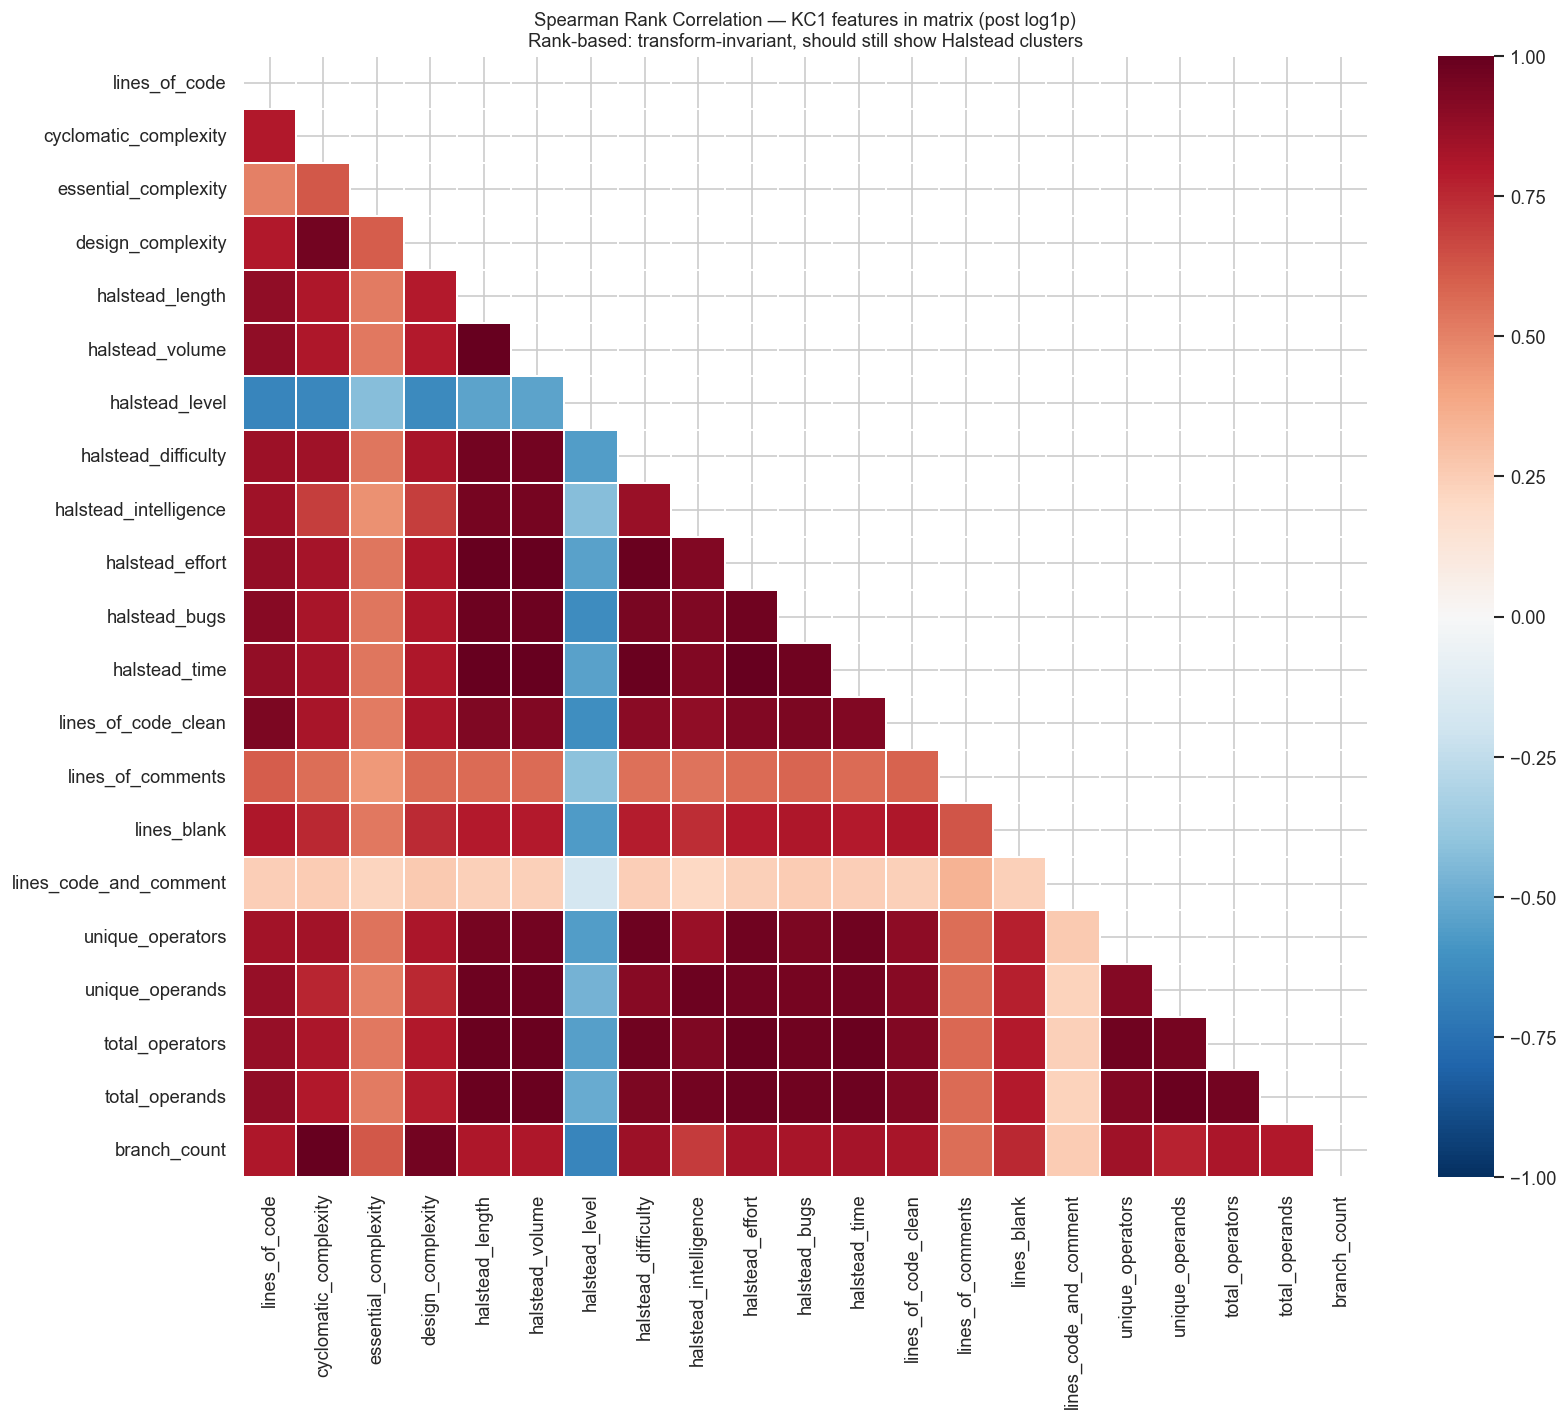

In [44]:
# ── 4b. Spearman on KC1 columns in the feature matrix (post log1p) ────────
kc1_in_matrix = [c for c in kc1_present if c in df.columns and df[c].notna().sum() > 10]
spearman_kc1 = df[kc1_in_matrix].corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 12))
mask2 = np.triu(np.ones_like(spearman_kc1, dtype=bool))
sns.heatmap(spearman_kc1, mask=mask2, annot=False,
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.2, ax=ax)
ax.set_title('Spearman Rank Correlation — KC1 features in matrix (post log1p)\n'
             'Rank-based: transform-invariant, should still show Halstead clusters', fontsize=11)
plt.tight_layout()
plt.show()

In [45]:
# ── 4c. Ranked high-correlation pairs ─────────────────────────────────────
def corr_pairs(corr_matrix, threshold):
    cols = corr_matrix.columns
    return sorted(
        [(cols[i], cols[j], corr_matrix.iloc[i, j])
         for i in range(len(cols))
         for j in range(i+1, len(cols))
         if abs(corr_matrix.iloc[i, j]) >= threshold],
        key=lambda x: -abs(x[2])
    )

for label, mat, method in [
    ('Pearson on raw KC1',       pearson_raw,  'r'),
    ('Spearman on KC1 in matrix', spearman_kc1, 'ρ'),
]:
    for thresh in (0.90, 0.70):
        pairs = corr_pairs(mat, thresh)
        print(f'{label}  |{method}| ≥ {thresh}: {len(pairs)} pairs')
        for a, b, r in pairs[:10]:
            print(f'  {a:<35s} {b:<35s} {method}={r:.3f}')
        if len(pairs) > 10:
            print(f'  … and {len(pairs)-10} more.')
        print()

Pearson on raw KC1  |r| ≥ 0.9: 58 pairs
  halstead_effort                     halstead_time                       r=1.000
  cyclomatic_complexity               branch_count                        r=0.999
  halstead_length                     total_operators                     r=0.998
  halstead_length                     total_operands                      r=0.995
  halstead_length                     halstead_volume                     r=0.995
  halstead_volume                     total_operators                     r=0.992
  halstead_volume                     total_operands                      r=0.992
  total_operators                     total_operands                      r=0.987
  lines_of_code                       lines_of_code_clean                 r=0.985
  halstead_volume                     halstead_bugs                       r=0.979
  … and 48 more.

Pearson on raw KC1  |r| ≥ 0.7: 135 pairs
  halstead_effort                     halstead_time                       r=1.000

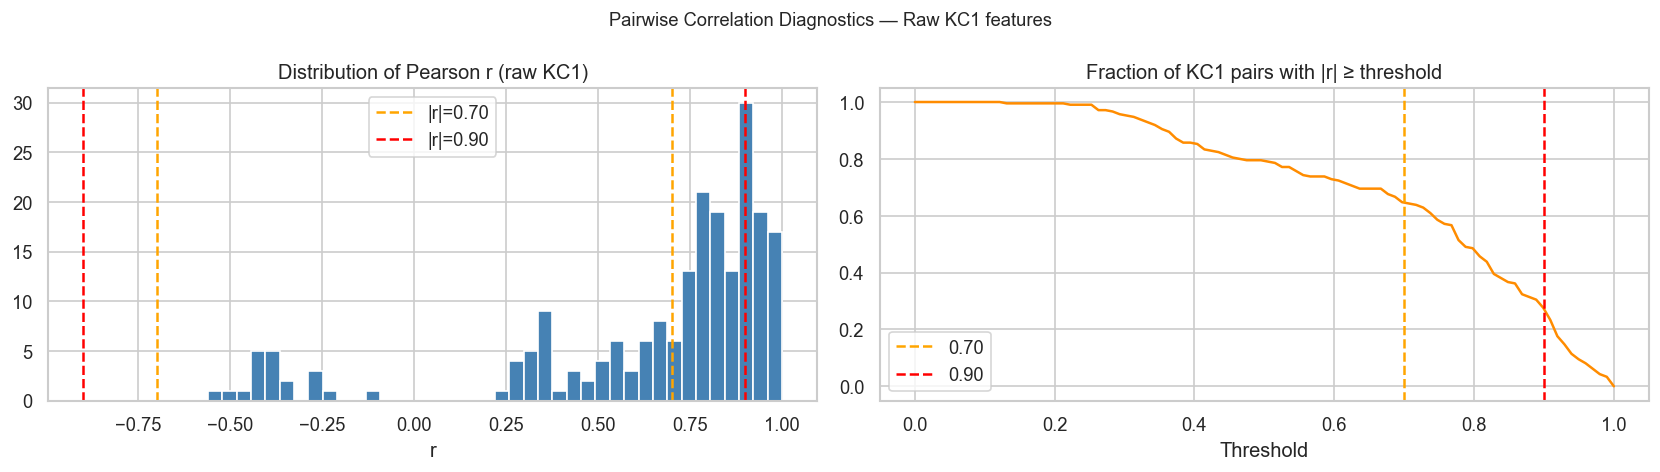

Total KC1 pairs         : 210
Pairs |r| ≥ 0.70        : 135
Pairs |r| ≥ 0.90        : 58
Max |r|                 : 1.000


In [46]:
# ── 4d. Distribution of pairwise correlations (KC1 raw) ───────────────────
triu = np.triu_indices_from(pearson_raw.values, k=1)
all_r = pearson_raw.values[triu]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(all_r, bins=40, color='steelblue', edgecolor='white')
for v, c, lbl in [(0.70,'orange','0.70'), (0.90,'red','0.90')]:
    axes[0].axvline( v, color=c, linestyle='--', label=f'|r|={lbl}')
    axes[0].axvline(-v, color=c, linestyle='--')
axes[0].set_title('Distribution of Pearson r (raw KC1)')
axes[0].set_xlabel('r')
axes[0].legend()

thresholds = np.linspace(0, 1, 100)
fractions  = [np.mean(np.abs(all_r) >= t) for t in thresholds]
axes[1].plot(thresholds, fractions, color='darkorange')
axes[1].set_title('Fraction of KC1 pairs with |r| ≥ threshold')
axes[1].set_xlabel('Threshold')
for v, c, lbl in [(0.70,'orange','0.70'), (0.90,'red','0.90')]:
    axes[1].axvline(v, color=c, linestyle='--', label=lbl)
axes[1].legend()
plt.suptitle('Pairwise Correlation Diagnostics — Raw KC1 features', fontsize=11)
plt.tight_layout()
plt.show()

print(f'Total KC1 pairs         : {len(all_r):,}')
print(f'Pairs |r| ≥ 0.70        : {np.sum(np.abs(all_r) >= 0.70):,}')
print(f'Pairs |r| ≥ 0.90        : {np.sum(np.abs(all_r) >= 0.90):,}')
print(f'Max |r|                 : {np.max(np.abs(all_r)):.3f}')

## 5. Top Features by Mutual Information

MI is computed on KC1-complete features only (process/AST are NaN-dominant and would need imputation that would distort results). NaN columns are excluded.

Features used for MI (21): ['lines_of_code', 'cyclomatic_complexity', 'essential_complexity', 'design_complexity', 'halstead_length', 'halstead_volume', 'halstead_level', 'halstead_difficulty', 'halstead_intelligence', 'halstead_effort', 'halstead_bugs', 'halstead_time', 'lines_of_code_clean', 'lines_of_comments', 'lines_blank', 'lines_code_and_comment', 'unique_operators', 'unique_operands', 'total_operators', 'total_operands', 'branch_count']


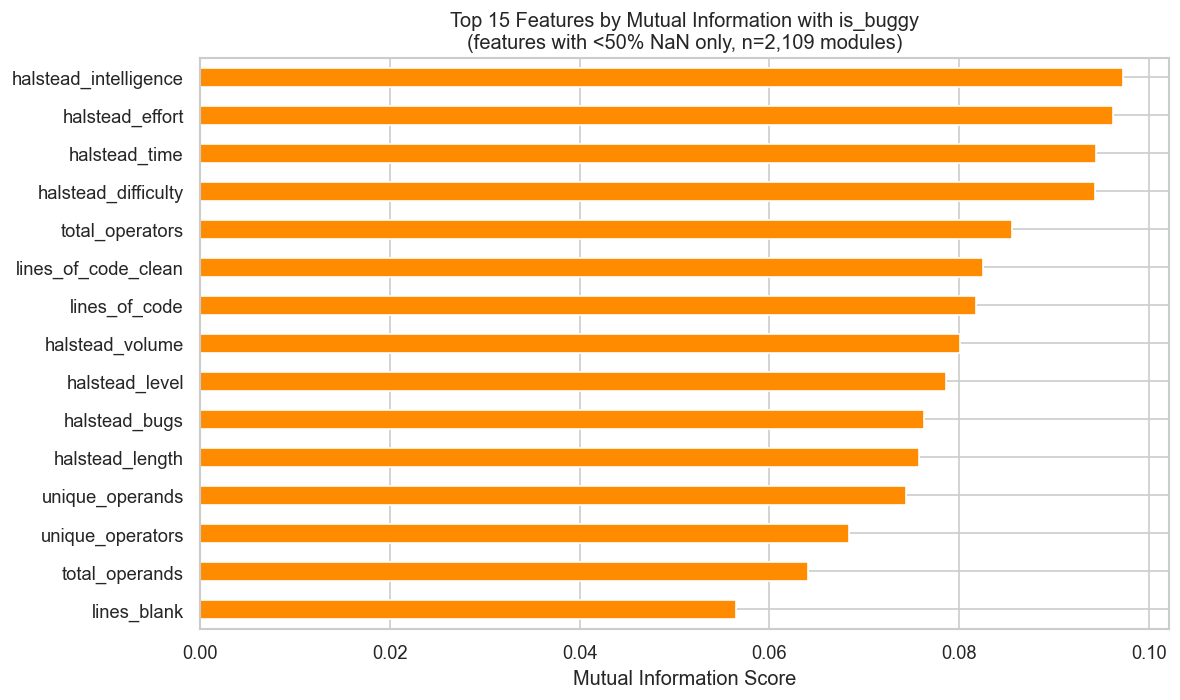


Full MI ranking:
halstead_intelligence     0.097188
halstead_effort           0.096166
halstead_time             0.094396
halstead_difficulty       0.094247
total_operators           0.085588
lines_of_code_clean       0.082469
lines_of_code             0.081757
halstead_volume           0.080089
halstead_level            0.078628
halstead_bugs             0.076298
halstead_length           0.075732
unique_operands           0.074397
unique_operators          0.068350
total_operands            0.064046
lines_blank               0.056509
cyclomatic_complexity     0.053034
branch_count              0.047530
design_complexity         0.043278
lines_of_comments         0.025310
essential_complexity      0.007871
lines_code_and_comment    0.000000


In [47]:
# Use only columns with < 50% NaN for MI (mostly KC1 features + any matched process/AST)
feature_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c != 'is_buggy' and df[c].isna().mean() < 0.5
]
print(f'Features used for MI ({len(feature_cols)}): {feature_cols}')

X = df[feature_cols].fillna(df[feature_cols].median())
y = df['is_buggy'].astype(int)

mi_scores = mutual_info_classif(X, y, discrete_features='auto', random_state=42)
mi_df = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

top_n = min(15, len(mi_df))
fig, ax = plt.subplots(figsize=(10, 6))
mi_df.head(top_n).plot(kind='barh', ax=ax, color='darkorange')
ax.invert_yaxis()
ax.set_title(f'Top {top_n} Features by Mutual Information with is_buggy\n'
             f'(features with <50% NaN only, n={len(X):,} modules)')
ax.set_xlabel('Mutual Information Score')
plt.tight_layout()
plt.show()

print('\nFull MI ranking:')
print(mi_df.to_string())

## 6. Day 2 End-of-Day Summary

In [48]:
buggy_n    = int(df['is_buggy'].sum())
clean_n    = int((df['is_buggy'] == 0).sum())
top3       = mi_df.head(3).index.tolist()
max_r      = float(np.max(np.abs(all_r)))
n_pairs_90 = int(np.sum(np.abs(all_r) >= 0.90))
proc_cov   = f"{coverage(proc_present):.0f}%" if proc_present else 'N/A'
ast_cov    = f"{coverage(ast_present):.0f}%"  if ast_present  else 'N/A'

print(f"""
╔══════════════════════════════════════════════════════════╗
║          Day 2 — Feature Engineering Complete            ║
╠══════════════════════════════════════════════════════════╣
║  Feature matrix shape : {df.shape[0]:>6,} rows × {df.shape[1]-2} features       ║
║  Buggy modules        : {buggy_n:>6,}                            ║
║  Clean modules        : {clean_n:>6,}                            ║
║  KC1 coverage         :  100%  ({len(kc1_present)} static cols)        ║
║  Process coverage     : {proc_cov:>5s}  (git match rate)          ║
║  AST coverage         : {ast_cov:>5s}  (source match rate)        ║
║  KC1 pairs |r| ≥ 0.90 : {n_pairs_90:>6,}  (max |r|={max_r:.3f})           ║
║  Top MI feature       : {top3[0]:<35s}║
║  2nd MI feature       : {top3[1]:<35s}║
║  3rd MI feature       : {top3[2]:<35s}║
╠══════════════════════════════════════════════════════════╣
║  Next: Day 3 — XGBoost + GNN model training              ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║          Day 2 — Feature Engineering Complete            ║
╠══════════════════════════════════════════════════════════╣
║  Feature matrix shape :  2,109 rows × 31 features       ║
║  Buggy modules        :    326                            ║
║  Clean modules        :  1,783                            ║
║  KC1 coverage         :  100%  (21 static cols)        ║
║  Process coverage     :   N/A  (git match rate)          ║
║  AST coverage         :    0%  (source match rate)        ║
║  KC1 pairs |r| ≥ 0.90 :     58  (max |r|=1.000)           ║
║  Top MI feature       : halstead_intelligence              ║
║  2nd MI feature       : halstead_effort                    ║
║  3rd MI feature       : halstead_time                      ║
╠══════════════════════════════════════════════════════════╣
║  Next: Day 3 — XGBoost + GNN model training              ║
╚══════════════════════════════════════════════════════════╝

